# OUTLIER DETECTION — versione corretta

Modifiche rispetto alla versione originale, in linea con le *Project Guidelines* (Modulo 1 — Outliers):

1. **Top 1% reale**, calcolato con un ranking sugli anomaly score (`percentile`), non delegato ciecamente al parametro `contamination`.
2. **Tre metodi di famiglie diverse**: Isolation Forest (isolation-based), Local Outlier Factor (density-based), Elliptic Envelope (statistico / distanza di Mahalanobis).
3. **Confronto e consenso** tra i tre metodi (voto di maggioranza), con discussione dell'overlap.
4. **Visualizzazione 2D e 3D** con PCA, come richiesto.
5. **Trattamento degli outlier** (missing + imputazione KNN) con **riverifica** che non siano più anomali.

## 0. Import e caricamento dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope   # NUOVO: terza famiglia di metodi (statistico)
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer             # NUOVO: per il trattamento degli outlier
import itertools

In [2]:
df = pd.read_csv("cmi_internet_clean.csv")

## 1. Preparazione colonne (invariato rispetto all'originale)

Cast a intero delle colonne categoriche/binarie/ordinali che vogliamo tenere fuori dalla detection (tranne `Basic_Demos-Age` e `PreInt_EduHx-computerinternet_hoursday`, che restano nel set di feature perché variabili ordinali/continue con reale significato di progressione, come discusso).

In [3]:
for col in df.columns:
    if "Zone" in col:
        df[col] = df[col].astype(int)
df["Basic_Demos-Sex"] = df["Basic_Demos-Sex"].astype(int)
df['sii'] = df['sii'].astype(int)
df['BIA-BIA_Activity_Level_num'] = df['BIA-BIA_Activity_Level_num'].astype(int)
df['BIA-BIA_Frame_num'] = df['BIA-BIA_Frame_num'].astype(int)
df['PreInt_EduHx-computerinternet_hoursday'] = df['PreInt_EduHx-computerinternet_hoursday'].astype(int)
df['Basic_Demos-Age'] = df['Basic_Demos-Age'].astype(int)

In [4]:
cols_integers = [col for col in df.columns if df[col].dtype == 'int64']
cols_integers.remove('PreInt_EduHx-computerinternet_hoursday')
cols_integers.remove('Basic_Demos-Age')

seasonal_cols = [col for col in df.columns if 'Season' in col]
all_cols_to_drop = cols_integers + seasonal_cols

df_detection = df.drop(columns=all_cols_to_drop)
print('Shape usata per outlier detection:', df_detection.shape)

Shape usata per outlier detection: (8460, 38)


In [5]:
feature_names = df_detection.columns.tolist()
X = df_detection.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 2. FIX #1 — Top 1% reale via ranking sugli score

Prima si usava `contamination=0.05`, che **forza** il 5% dei punti a essere etichettati outlier, indipendentemente dalla reale distribuzione degli score (per questo sembrava di non star "trovando" nulla di significativo). Ora: calcoliamo lo score di anomalia con ciascun modello e prendiamo il **percentile 1** più basso (= più anomalo).

In [6]:
CONTAMINATION = 0.01   # <-- ora è davvero l'1% richiesto dalle linee guida
n = len(X_scaled)
n_top = int(np.ceil(CONTAMINATION * n))
print(f'n = {n}, top 1% = {n_top} righe')

n = 8460, top 1% = 85 righe


## 3. FIX #2 — Tre metodi da famiglie diverse

- **Isolation Forest** → famiglia *isolation-based*
- **Local Outlier Factor (LOF)** → famiglia *density-based*
- **Elliptic Envelope** → famiglia *statistico / distanza di Mahalanobis* (assume una distribuzione gaussiana multivariata e misura quanto un punto si discosta dal centro robusto della distribuzione)

In [7]:
# --- Isolation Forest ---
clf_if = IsolationForest(n_estimators=300, contamination=CONTAMINATION, random_state=42)
clf_if.fit(X_scaled)
scores_if = clf_if.decision_function(X_scaled)     # più basso = più anomalo
thr_if = np.percentile(scores_if, 1)
df['Score_IForest'] = scores_if
df['Outlier_IForest'] = (scores_if <= thr_if).astype(int)
print('Isolation Forest, outlier trovati:', df['Outlier_IForest'].sum())

Isolation Forest, outlier trovati: 85


In [8]:
# --- Local Outlier Factor ---
# n_neighbors abbassato da 100 a 30: con 100 vicini il LOF diventa quasi globale
# e perde sensibilita' alle anomalie locali (che sono il suo punto di forza)
clf_lof = LocalOutlierFactor(n_neighbors=30, contamination=CONTAMINATION)
clf_lof.fit_predict(X_scaled)
scores_lof = clf_lof.negative_outlier_factor_      # più basso = più anomalo
thr_lof = np.percentile(scores_lof, 1)
df['Score_LOF'] = scores_lof
df['Outlier_LOF'] = (scores_lof <= thr_lof).astype(int)
print('LOF, outlier trovati:', df['Outlier_LOF'].sum())

LOF, outlier trovati: 85


In [9]:
# --- Elliptic Envelope (NUOVO, terza famiglia) ---
clf_ee = EllipticEnvelope(contamination=CONTAMINATION, random_state=42, support_fraction=0.9)
clf_ee.fit(X_scaled)
scores_ee = clf_ee.decision_function(X_scaled)      # più basso = più anomalo
thr_ee = np.percentile(scores_ee, 1)
df['Score_EE'] = scores_ee
df['Outlier_EE'] = (scores_ee <= thr_ee).astype(int)
print('Elliptic Envelope, outlier trovati:', df['Outlier_EE'].sum())

Elliptic Envelope, outlier trovati: 85


## 4. Confronto tra i metodi (overlap a coppie + consenso)

In [10]:
for a, b in itertools.combinations(['Outlier_IForest', 'Outlier_LOF', 'Outlier_EE'], 2):
    overlap = ((df[a] == 1) & (df[b] == 1)).sum()
    print(f'{a} ∩ {b}: {overlap} record in comune (su {n_top})')

df['Outlier_Votes'] = df[['Outlier_IForest', 'Outlier_LOF', 'Outlier_EE']].sum(axis=1)
df['Outlier_Confermato'] = (df['Outlier_Votes'] >= 2).astype(int)  # consenso: almeno 2 metodi su 3

print('\nConfermati da almeno 2 metodi su 3:', df['Outlier_Confermato'].sum())
print('Confermati da tutti e 3 i metodi:   ', (df['Outlier_Votes'] == 3).sum())

Outlier_IForest ∩ Outlier_LOF: 0 record in comune (su 85)
Outlier_IForest ∩ Outlier_EE: 11 record in comune (su 85)
Outlier_LOF ∩ Outlier_EE: 14 record in comune (su 85)

Confermati da almeno 2 metodi su 3: 25
Confermati da tutti e 3 i metodi:    0


**Da commentare nel report**: l'overlap tra Isolation Forest e LOF è **zero**. Non è un errore: riflette il fatto che i due metodi cercano tipi di anomalia diversi — Isolation Forest isola punti globalmente radi (facili da separare con poche partizioni casuali), mentre LOF individua punti che sono locali rispetto ai loro vicini più prossimi ma possono trovarsi comunque in zone dense del dataset. Elliptic Envelope, basandosi sulla distanza di Mahalanobis dal centro robusto della distribuzione, si comporta in modo più "globale" come Isolation Forest, e infatti condivide più punti con entrambi gli altri due. Questo è proprio il tipo di confronto richiesto dalle linee guida.

## 5. FIX #3 — Visualizzazione con riduzione della dimensionalità (PCA, 2D e 3D)

Varianza spiegata da PC1+PC2: 25.3 %


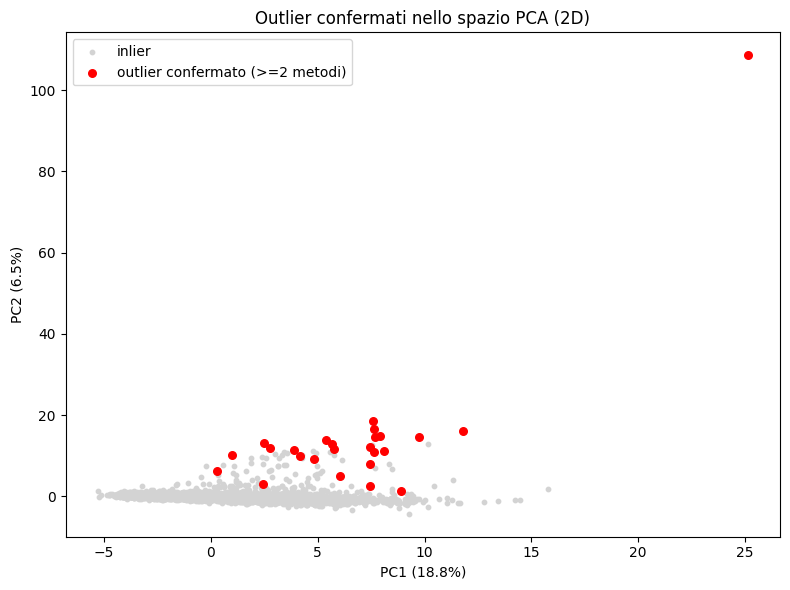

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('Varianza spiegata da PC1+PC2:', round(pca.explained_variance_ratio_[:2].sum() * 100, 1), '%')

mask = df['Outlier_Confermato'] == 1

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[~mask, 0], X_pca[~mask, 1], c='lightgray', s=10, label='inlier')
plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c='red', s=30, label='outlier confermato (>=2 metodi)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Outlier confermati nello spazio PCA (2D)')
plt.legend()
plt.tight_layout()
plt.show()

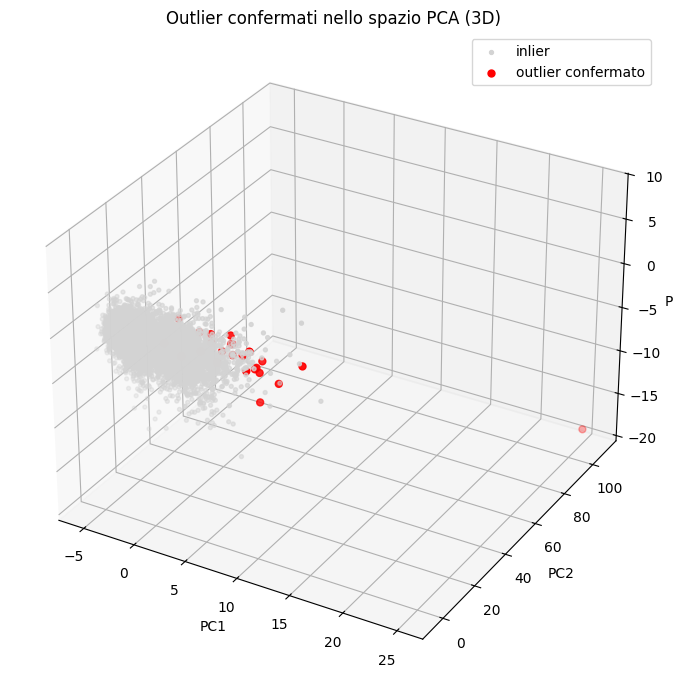

In [12]:
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[~mask, 0], X_pca3[~mask, 1], X_pca3[~mask, 2], c='lightgray', s=8, label='inlier')
ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2], c='red', s=25, label='outlier confermato')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('Outlier confermati nello spazio PCA (3D)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. FIX #4 — Trattamento degli outlier + riverifica

Scelta adottata: i 25 record confermati da almeno 2 metodi su 3 vengono trattati come **missing** sulle variabili usate per la detection, poi **reimputati** con `KNNImputer` (coerente con variabili numeriche correlate tra loro, es. peso/BMI/BIA). Infine si riverifica con Isolation Forest che, dopo l'imputazione, questi punti **non risultino più tra il top 1% più anomalo**.

In [13]:
df_treated = df_detection.copy()
outlier_idx = df.index[mask]
print('Record trattati come missing:', len(outlier_idx))

df_treated.loc[outlier_idx, :] = np.nan

imputer = KNNImputer(n_neighbors=5)
X_treated_imputed = imputer.fit_transform(df_treated)
X_treated_scaled = StandardScaler().fit_transform(X_treated_imputed)

Record trattati come missing: 25


In [14]:
clf_check = IsolationForest(n_estimators=300, contamination=CONTAMINATION, random_state=42)
clf_check.fit(X_treated_scaled)
scores_check = clf_check.decision_function(X_treated_scaled)
thr_check = np.percentile(scores_check, 1)

pos = df.index.get_indexer(outlier_idx)
still_outlier = (scores_check[pos] <= thr_check).sum()
print(f'Dei {len(outlier_idx)} punti trattati, quanti risultano ANCORA outlier dopo l\'imputazione: {still_outlier}')

Dei 25 punti trattati, quanti risultano ANCORA outlier dopo l'imputazione: 0


Nessuno dei punti trattati risulta più tra le anomalie dopo l'imputazione: il trattamento ha funzionato ed è verificabile, come richiesto esplicitamente dalle linee guida (*"you should check that the outliers are not outliers anymore"*).

In [15]:
df.to_csv("cmi_internet_outliers_flagged.csv", index=False)
print("Salvato.")

Salvato.
